<a href="https://colab.research.google.com/github/Prarambhh/Handwritten-Digit-Classification-with-a-Neural-Network-MNIST/blob/main/MNIST_Handwritten_Digit_Classification_with_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MNIST Handwritten Digit Classification with Neural Network**

In [1]:
#importing dependencies

import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
tf.random.set_seed(3)
from keras.datasets import mnist
from tensorflow.math import confusion_matrix



Loading MNIST data from keras.datasets

In [2]:
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
type(X_train)

numpy.ndarray

In [4]:
# shape of the numpy arrays

print("X_train shape:", X_train.shape)
print("Y_train shape:", Y_train.shape)
print("X_test shape:", X_test.shape)
print("Y_test shape:", Y_test.shape)

X_train shape: (60000, 28, 28)
Y_train shape: (60000,)
X_test shape: (10000, 28, 28)
Y_test shape: (10000,)


Training data = 60000 images ;
Testing data = 10000 images

Image dimention is 28 x 28 ;
grayscale image 1 channel

In [6]:
#printing the 10th image
print(X_train[9])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0 189 190   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0 143 247 153   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0 136 247 242  86   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0 192 252 187   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  62 185  18   

In [7]:
print(X_train[9].shape)


(28, 28)


3


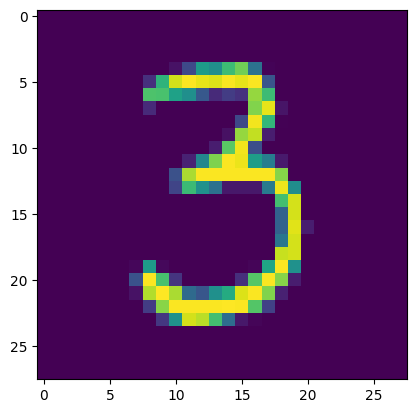

In [9]:
#displaying the image
plt.imshow(X_train[50])
plt.show

#printing the corresponding label

print(Y_train[50])

3


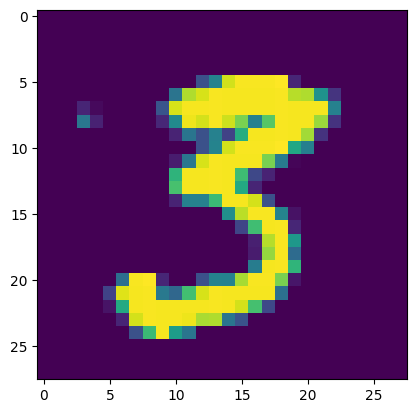

In [10]:
#displaying the image
plt.imshow(X_train[49])
plt.show

#printing the corresponding label

print(Y_train[49])

Image Labels

In [11]:
print(Y_train.shape, Y_test.shape)

(60000,) (10000,)


In [13]:
#unique values in Y train

print(np.unique(Y_train))

#unique values in Y test

print(np.unique(Y_test))

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]


All the images have the same dimmentions in this dataset,If not,we have to resize them all the images to a common dimention

We can use these labels as such or we can also apply One Hot Encoding

In [15]:
#scaling the values

#all the values are currently ranging from 0 to 255 (it tells us the intensity of the colour)

#now we are converting the values in the range 0 to 1

X_train_scaled = X_train/255
X_test_scaled = X_test/255


In [16]:
print(X_train_scaled[10])

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.    

Building the Neural Network

In [17]:
#We are not using CNN here
#We are resorting to basic neural network here for this project

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(50, activation='relu'),
    keras.layers.Dense(10, activation ='sigmoid')])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [18]:
#compiling the NN

model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [19]:
#training NN

model.fit(X_train_scaled, Y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8493 - loss: 0.5146
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9550 - loss: 0.1523
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9682 - loss: 0.1083
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9746 - loss: 0.0845
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9793 - loss: 0.0697
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9823 - loss: 0.0579
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9851 - loss: 0.0487
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9875 - loss: 0.0415
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9892 - loss: 0.0359
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9899 - loss: 0.0329


Training data accuracy = 98.99%

**Accuracy on Test data**

In [20]:
loss,accuracy = model.evaluate(X_test_scaled, Y_test)
print("Test loss:", loss)
print("Test accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9599 - loss: 0.1539
Test loss: 0.1377284973859787
Test accuracy: 0.9645000100135803


Test data accuracy = 95.99%

<function matplotlib.pyplot.show(close=None, block=None)>

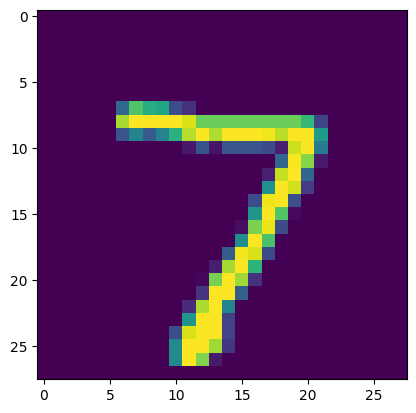

In [22]:
#first data point in X_test

plt.imshow(X_test[0])
plt.show

In [23]:
print(Y_test[0])

7


In [24]:
Y_pred = model.predict(X_test_scaled)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [25]:
print(Y_pred.shape)

(10000, 10)


In [26]:
print(Y_pred[0])

[5.64385299e-03 3.92056778e-02 3.66359018e-02 8.82503927e-01
 7.18075288e-09 1.38890721e-06 1.05803206e-10 9.99999404e-01
 6.54241419e-04 4.43306714e-01]


model.predict() gives the prediction probability of each class for that data point

In [27]:
#converting the prediction probabilities to class label

label_for_first_test_image = np.argmax(Y_pred[0])
print(label_for_first_test_image)

7


In [28]:
#converting the prediction probabilities to class label for all test data points

Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)


[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4), np.int64(1), np.int64(4), np.int64(9), np.int64(5), np.int64(9), np.int64(0), np.int64(6), np.int64(9), np.int64(0), np.int64(1), np.int64(5), np.int64(9), np.int64(7), np.int64(3), np.int64(4), np.int64(9), np.int64(6), np.int64(6), np.int64(5), np.int64(4), np.int64(0), np.int64(7), np.int64(4), np.int64(0), np.int64(1), np.int64(3), np.int64(1), np.int64(3), np.int64(4), np.int64(7), np.int64(2), np.int64(7), np.int64(1), np.int64(3), np.int64(1), np.int64(1), np.int64(7), np.int64(4), np.int64(2), np.int64(3), np.int64(5), np.int64(1), np.int64(2), np.int64(4), np.int64(4), np.int64(6), np.int64(3), np.int64(5), np.int64(5), np.int64(6), np.int64(0), np.int64(4), np.int64(1), np.int64(9), np.int64(5), np.int64(7), np.int64(8), np.int64(9), np.int64(3), np.int64(7), np.int64(4), np.int64(6), np.int64(4), np.int64(3), np.int64(0), np.int64(7), np.int64(0), np.int64(2), np.int64(9), np.int64(1), np.int64(7), np.int64(3)

Y_test -->True labels ;;
Y_pred_labels -->Predicted labels

Confusion matrix

In [29]:
conf_mat = confusion_matrix(Y_test, Y_pred_labels)
print(conf_mat)

tf.Tensor(
[[ 931    0    2    2    1    5   11    5    2   21]
 [   0 1114    1    8    0    1    6    1    4    0]
 [   3    1  996   18    0    0    2    4    8    0]
 [   0    0    2  997    0    0    0    5    3    3]
 [   0    0    5    0  956    0    6    5    2    8]
 [   1    0    0   40    4  830    8    2    7    0]
 [   4    2    3    1    5    7  935    0    1    0]
 [   1    1   11    6    3    0    0  999    0    7]
 [   0    0    5   22    5    7    1    4  926    4]
 [   0    3    1    7   14    5    0   15    4  960]], shape=(10, 10), dtype=int32)


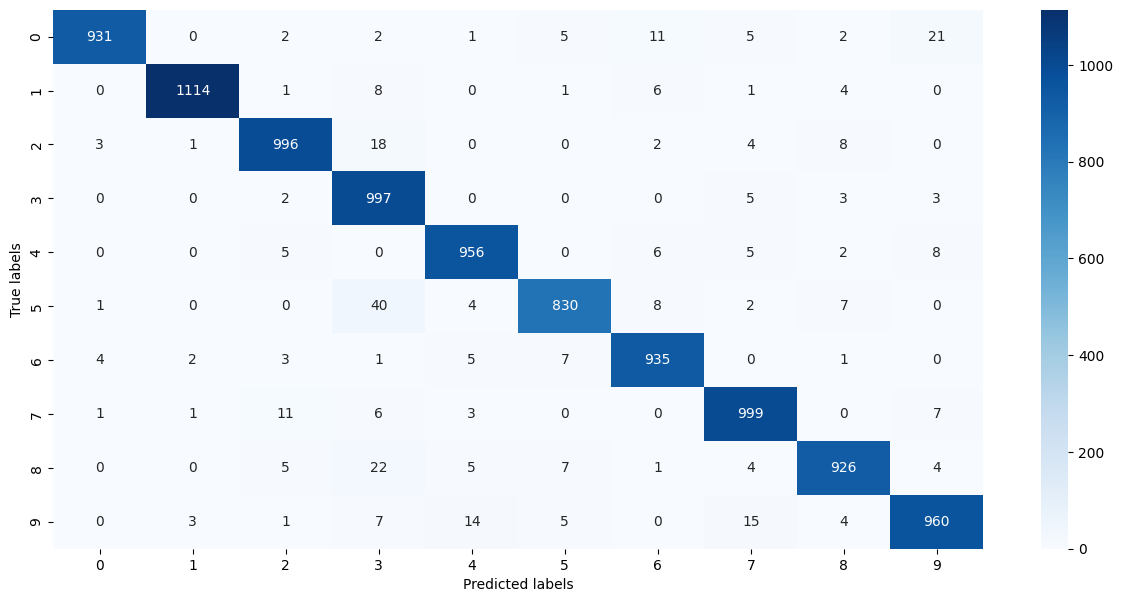

In [31]:
plt.figure(figsize = (15,7))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True labels')
plt.xlabel('Predicted labels')
plt.show()


BUILDING A PREDICTIVE SYSTEM

In [32]:
input_image_path = '/content/MNIST_digit.png'

input_image = cv2.imread(input_image_path)


In [33]:
type(input_image)

numpy.ndarray

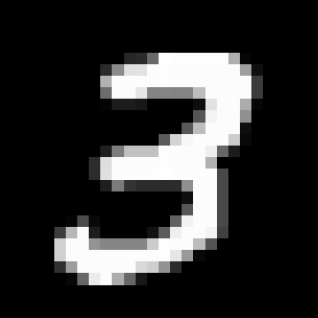

In [34]:
cv2_imshow(input_image)

In [35]:
input_image.shape

(318, 318, 3)

Need to convert this image into greyscale image

In [36]:
grayscale = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

In [37]:
grayscale.shape

(318, 318)

In [38]:
input_image_resize = cv2.resize(grayscale, (28,28))

In [39]:
print(input_image_resize.shape)

(28, 28)


In [40]:
cv2_imshow(input_image_resize)

In [41]:
input_image_resize = input_image_resize/255

image_reshaped = np.reshape(input_image_resize, [1,28,28])

In [42]:
input_prediction = model.predict(image_reshaped)
print(input_prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
[[6.6287531e-11 7.8212373e-02 1.9312863e-01 1.0000000e+00 3.6061642e-18
  6.3666496e-03 2.7032511e-19 7.7823615e-01 1.6673004e-02 1.4284526e-01]]


In [43]:
input_pred_label = np.argmax(input_prediction)

In [44]:
print(input_pred_label)

3


**PREDICTIVE SYSTEM**

Enter the path of the image to be predicted: /content/MNIST_digit.png


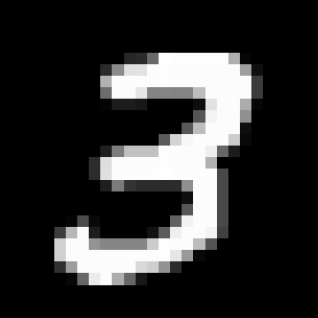

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
The Handwritten Digit is recognized as  3


In [45]:
input_image_path = input("Enter the path of the image to be predicted: ")

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

grayscale = cv2.cvtColor(input_image, cv2.COLOR_BGR2GRAY)

input_image_resize = cv2.resize(grayscale, (28,28))

input_image_resize = input_image_resize/255

image_reshaped = np.reshape(input_image_resize, [1,28,28])

input_prediction = model.predict(image_reshaped)

input_pred_label = np.argmax(input_prediction)

print('The Handwritten Digit is recognized as ', input_pred_label)